In [15]:
import requests
import re

In [29]:
def load_texts(list):
  texts=[]
  for i in list:
    response = requests.get(i)
    text = re.sub(r'\W+', ' ', response.text)
    texts.append(response.text)
  return texts

In [30]:
books_list=["https://www.gutenberg.org/cache/epub/11/pg11.txt",
      "https://www.gutenberg.org/cache/epub/12/pg12.txt",
      "https://www.gutenberg.org/cache/epub/29042/pg29042.txt"]

In [31]:
texts=load_texts(books_list)

In [32]:
def clean_text(text):
  start_index = text.find('START OF THE PROJECT GUTENBERG EBOOK') + len('START OF THE PROJECT GUTENBERG EBOOK')
  end_index = text.find('*** END')
  return text[start_index:end_index]

cleaned_texts = [clean_text(text) for text in texts]

for text in cleaned_texts:
  print(text[:200])

 ALICE'S ADVENTURES IN WONDERLAND ***
[Illustration]




Alice’s Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION 3.0

Contents

 CHAPTER I.     Down the Rabbit
 THROUGH THE LOOKING-GLASS ***




[Illustration]




THROUGH THE LOOKING-GLASS

And What Alice Found There

By Lewis Carroll

The Millennium Fulcrum Edition 1.7




DRAMATIS PERS
 A TANGLED TALE ***




Produced by Chris Curnow, Carla Foust, Lindy Walsh and the
Online Distributed Proofreading Team at https://www.pgdp.net.
Music transcribed by Linda Cantoni.





T


In [20]:
import nltk
nltk.download('punkt')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('stopwords')
from nltk.stem import PorterStemmer

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [33]:
tokenized_texts = [word_tokenize(text) for text in cleaned_texts]

for tokens in tokenized_texts:
  print(tokens[:150])

['ALICE', "'S", 'ADVENTURES', 'IN', 'WONDERLAND', '*', '*', '*', '[', 'Illustration', ']', 'Alice', '’', 's', 'Adventures', 'in', 'Wonderland', 'by', 'Lewis', 'Carroll', 'THE', 'MILLENNIUM', 'FULCRUM', 'EDITION', '3.0', 'Contents', 'CHAPTER', 'I', '.', 'Down', 'the', 'Rabbit-Hole', 'CHAPTER', 'II', '.', 'The', 'Pool', 'of', 'Tears', 'CHAPTER', 'III', '.', 'A', 'Caucus-Race', 'and', 'a', 'Long', 'Tale', 'CHAPTER', 'IV', '.', 'The', 'Rabbit', 'Sends', 'in', 'a', 'Little', 'Bill', 'CHAPTER', 'V.', 'Advice', 'from', 'a', 'Caterpillar', 'CHAPTER', 'VI', '.', 'Pig', 'and', 'Pepper', 'CHAPTER', 'VII', '.', 'A', 'Mad', 'Tea-Party', 'CHAPTER', 'VIII', '.', 'The', 'Queen', '’', 's', 'Croquet-Ground', 'CHAPTER', 'IX', '.', 'The', 'Mock', 'Turtle', '’', 's', 'Story', 'CHAPTER', 'X', '.', 'The', 'Lobster', 'Quadrille', 'CHAPTER', 'XI', '.', 'Who', 'Stole', 'the', 'Tarts', '?', 'CHAPTER', 'XII', '.', 'Alice', '’', 's', 'Evidence', 'CHAPTER', 'I', '.', 'Down', 'the', 'Rabbit-Hole', 'Alice', 'was', 'b

In [34]:
stop_words = set(stopwords.words('english'))

filtered_texts = []
for tokens in tokenized_texts:
  filtered_tokens = [word for word in tokens if word.lower() not in stop_words]
  filtered_texts.append(filtered_tokens)

stop_words_to_check = ['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves']
for tokens in filtered_texts:
  for stop_word in stop_words_to_check:
    count = tokens.count(stop_word)
    print(f"Count of '{stop_word}' in text: {count}")


Count of 'i' in text: 0
Count of 'me' in text: 0
Count of 'my' in text: 0
Count of 'myself' in text: 0
Count of 'we' in text: 0
Count of 'our' in text: 0
Count of 'ours' in text: 0
Count of 'ourselves' in text: 0
Count of 'i' in text: 0
Count of 'me' in text: 0
Count of 'my' in text: 0
Count of 'myself' in text: 0
Count of 'we' in text: 0
Count of 'our' in text: 0
Count of 'ours' in text: 0
Count of 'ourselves' in text: 0
Count of 'i' in text: 0
Count of 'me' in text: 0
Count of 'my' in text: 0
Count of 'myself' in text: 0
Count of 'we' in text: 0
Count of 'our' in text: 0
Count of 'ours' in text: 0
Count of 'ourselves' in text: 0


In [35]:
stemmer = PorterStemmer()
stemmed_tokens = [[stemmer.stem(word) for word in tokens] for tokens in filtered_texts]

for tokens in stemmed_tokens:
  print(tokens[:50])

['alic', "'s", 'adventur', 'wonderland', '*', '*', '*', '[', 'illustr', ']', 'alic', '’', 'adventur', 'wonderland', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', '3.0', 'content', 'chapter', '.', 'rabbit-hol', 'chapter', 'ii', '.', 'pool', 'tear', 'chapter', 'iii', '.', 'caucus-rac', 'long', 'tale', 'chapter', 'iv', '.', 'rabbit', 'send', 'littl', 'bill', 'chapter', 'v.', 'advic', 'caterpillar', 'chapter', 'vi', '.', 'pig']
['looking-glass', '*', '*', '*', '[', 'illustr', ']', 'looking-glass', 'alic', 'found', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', '1.7', 'dramati', 'personæ', '.', '(', '_a', 'arrang', 'commenc', 'game._', ')', 'white', 'red', '.', 'piec', '.', 'pawn', '.', 'pawn', '.', 'piec', '.', 'tweedlede', '.', 'daisi', '.', 'daisi', '.', 'humpti', 'dumpti', '.', 'unicorn', '.', 'haigha', '.', 'messeng']
['tangl', 'tale', '*', '*', '*', 'produc', 'chri', 'curnow', ',', 'carla', 'foust', ',', 'lindi', 'walsh', 'onlin', 'distribut', 'proofread', 'team', 'http', ':'

In [36]:
import spacy

nlp = spacy.load('en_core_web_sm')
lemmatized_texts = []

for text in cleaned_texts:
  doc = nlp(text)
  filtered_texts = [token for token in doc if not token.is_stop]
  lemmatized_tokens = [token.lemma_ for token in filtered_texts]
  lemmatized_texts.append(lemmatized_tokens)

for tokens in lemmatized_texts:
  print(tokens[:50])


[' ', 'ALICE', 'adventures', 'WONDERLAND', '*', '*', '*', '\r\n', '[', 'illustration', ']', '\r\n\r\n\r\n\r\n\r\n', 'Alice', 'Adventures', 'Wonderland', '\r\n\r\n', 'Lewis', 'Carroll', '\r\n\r\n', 'MILLENNIUM', 'FULCRUM', 'EDITION', '3.0', '\r\n\r\n', 'Contents', '\r\n\r\n ', 'CHAPTER', 'I.', '    ', 'Rabbit', '-', 'Hole', '\r\n ', 'CHAPTER', 'II', '.', '   ', 'Pool', 'Tears', '\r\n ', 'CHAPTER', 'III', '.', '  ', 'Caucus', '-', 'Race', 'Long', 'Tale', '\r\n ']
[' ', 'LOOKING', '-', 'GLASS', '*', '*', '*', '\r\n\r\n\r\n\r\n\r\n', '[', 'illustration', ']', '\r\n\r\n\r\n\r\n\r\n', 'LOOKING', '-', 'GLASS', '\r\n\r\n', 'Alice', 'find', '\r\n\r\n', 'Lewis', 'Carroll', '\r\n\r\n', 'Millennium', 'Fulcrum', 'Edition', '1.7', '\r\n\r\n\r\n\r\n\r\n', 'DRAMATIS', 'PERSONÆ', '.', '\r\n', '(', '_', 'arrange', 'commencement', 'game', '.', '_', ')', '\r\n\r\n', 'WHITE', '                       ', 'RED', '.', '\r\n', 'PIECES', '.', '       ', 'PAWNS', '.']
[' ', 'tangled', 'TALE', '*', '*', '*', '\r\n

PorterStemmer - removes more irrelevant words

SpaCy - more accurate with roots

In [38]:
from nltk import pos_tag, ne_chunk

In [39]:
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!


True

In [40]:
pos_tags = []
for tokens in tokenized_texts:
  pos_tags.append(pos_tag(tokens))

for tags in pos_tags:
  print(tags[:50])

[('ALICE', 'NNP'), ("'S", 'POS'), ('ADVENTURES', 'NNP'), ('IN', 'NNP'), ('WONDERLAND', 'NNP'), ('*', 'NNP'), ('*', 'NNP'), ('*', 'NNP'), ('[', 'NNP'), ('Illustration', 'NNP'), (']', 'NNP'), ('Alice', 'NNP'), ('’', 'NNP'), ('s', 'NN'), ('Adventures', 'NNP'), ('in', 'IN'), ('Wonderland', 'NNP'), ('by', 'IN'), ('Lewis', 'NNP'), ('Carroll', 'NNP'), ('THE', 'NNP'), ('MILLENNIUM', 'NNP'), ('FULCRUM', 'NNP'), ('EDITION', 'NNP'), ('3.0', 'CD'), ('Contents', 'NNP'), ('CHAPTER', 'NN'), ('I', 'PRP'), ('.', '.'), ('Down', 'RP'), ('the', 'DT'), ('Rabbit-Hole', 'JJ'), ('CHAPTER', 'NNP'), ('II', 'NNP'), ('.', '.'), ('The', 'DT'), ('Pool', 'NNP'), ('of', 'IN'), ('Tears', 'NNP'), ('CHAPTER', 'NNP'), ('III', 'NNP'), ('.', '.'), ('A', 'DT'), ('Caucus-Race', 'NN'), ('and', 'CC'), ('a', 'DT'), ('Long', 'JJ'), ('Tale', 'NNP'), ('CHAPTER', 'NNP'), ('IV', 'NNP')]
[('THROUGH', 'IN'), ('THE', 'DT'), ('LOOKING-GLASS', 'NNP'), ('*', 'NNP'), ('*', 'NNP'), ('*', 'NNP'), ('[', 'NNP'), ('Illustration', 'NNP'), (']', 

In [41]:
named_entities = []
for tokens in tokenized_texts:
  entities = ne_chunk(pos_tag(tokens))
  named_entities.append(entities)

for entities in named_entities:
  print(entities[:50])

[('ALICE', 'NNP'), ("'S", 'POS'), Tree('ORGANIZATION', [('ADVENTURES', 'NNP')]), ('IN', 'NNP'), ('WONDERLAND', 'NNP'), ('*', 'NNP'), ('*', 'NNP'), ('*', 'NNP'), ('[', 'NNP'), ('Illustration', 'NNP'), (']', 'NNP'), ('Alice', 'NNP'), ('’', 'NNP'), ('s', 'NN'), ('Adventures', 'NNP'), ('in', 'IN'), Tree('GPE', [('Wonderland', 'NNP')]), ('by', 'IN'), Tree('PERSON', [('Lewis', 'NNP'), ('Carroll', 'NNP'), ('THE', 'NNP')]), Tree('ORGANIZATION', [('MILLENNIUM', 'NNP')]), ('FULCRUM', 'NNP'), ('EDITION', 'NNP'), ('3.0', 'CD'), ('Contents', 'NNP'), ('CHAPTER', 'NN'), ('I', 'PRP'), ('.', '.'), ('Down', 'RP'), ('the', 'DT'), ('Rabbit-Hole', 'JJ'), ('CHAPTER', 'NNP'), ('II', 'NNP'), ('.', '.'), ('The', 'DT'), Tree('ORGANIZATION', [('Pool', 'NNP')]), ('of', 'IN'), Tree('PERSON', [('Tears', 'NNP')]), ('CHAPTER', 'NNP'), ('III', 'NNP'), ('.', '.'), ('A', 'DT'), ('Caucus-Race', 'NN'), ('and', 'CC'), ('a', 'DT'), Tree('ORGANIZATION', [('Long', 'JJ'), ('Tale', 'NNP')]), ('CHAPTER', 'NNP'), ('IV', 'NNP'), (

# Analysing the text

1. using wordcloud and matplotlib, display a word cloud of each book.

In [42]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

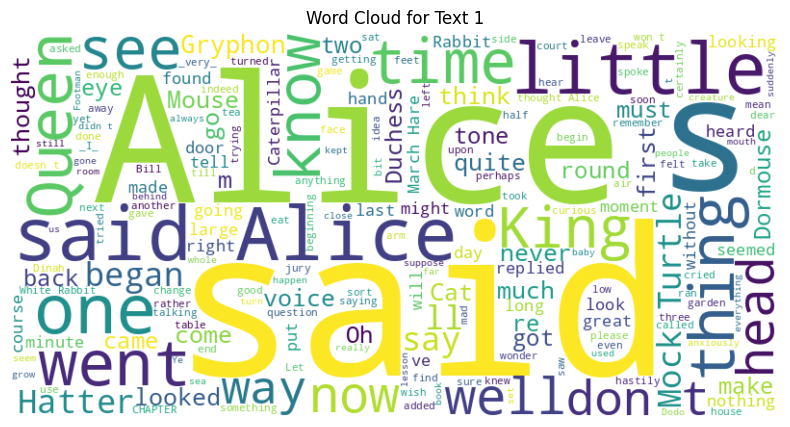

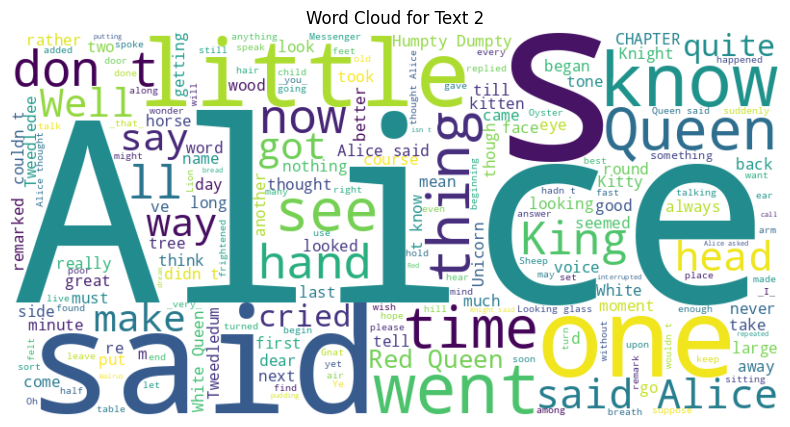

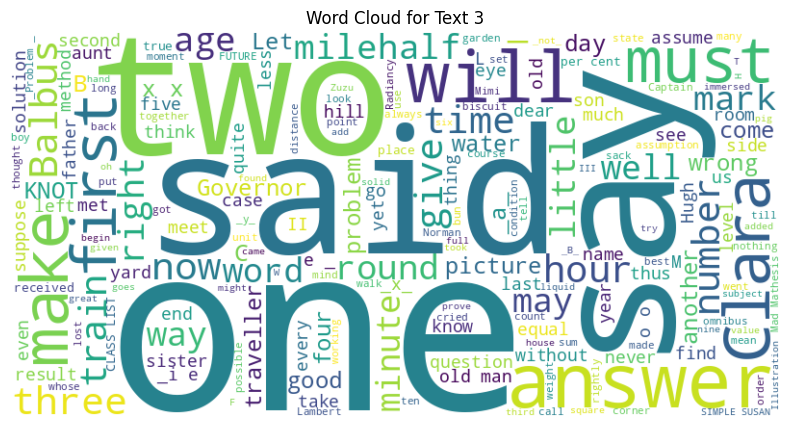

In [45]:
for i, text in enumerate(cleaned_texts):
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Word Cloud for Text {i+1}')
        plt.show()

2. Use BoW method to check the five most frequent words in all the books

In [46]:
from collections import Counter

In [61]:
def find_most_frequent_words(ar, top_n=5):
    for i, text in enumerate(ar):
        word_freq = Counter(tokens)
        most_common_words = word_freq.most_common(top_n)
        print(f"Top {top_n} most frequent words in Text {i+1}:")
        for word, freq in most_common_words:
            print(f"{word}: {freq}")
        print("\n")